# <a id='toc1_'></a>[Technische Prüfungen in klinischen und epi Daten](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [Technische Prüfungen in klinischen und epi Daten](#toc1_)    
  - [Hintergrund](#toc1_1_)    
  - [Zusammenfassung ⚖️](#toc1_2_)    
  - [⚙️ settings](#toc1_3_)    
  - [Datenstand ⏱️](#toc1_4_)    
  - [Qualitätsprüfungen](#toc1_5_)    
    - [⚠️ geschlecht_missing](#toc1_5_1_)    
    - [✅ verstorben_missing](#toc1_5_2_)    
    - [⚠️ diagnose_missing](#toc1_5_3_)    
    - [⚠️ inzidenzort_missing](#toc1_5_4_)    
    - [✅ geschlecht_icd_konflikt](#toc1_5_5_)    
    - [⚠️ datum_missing](#toc1_5_6_)    
    - [datum_fehlerhaft](#toc1_5_7_)    
  - [⚠️ Duplikate](#toc1_6_)    
    - [Echte Duplikate](#toc1_6_1_)    
    - [Duplikatverdacht](#toc1_6_2_)    
      - [Verteilung nach Inzidenzort](#toc1_6_2_1_)    
      - [Verteilung nach Diagnosejahr](#toc1_6_2_2_)    
      - [Verteilung nach ICD10](#toc1_6_2_3_)    
      - [Verteilung der Gruppen mit gleichen Merkmalen](#toc1_6_2_4_)    
  - [Datensatz](#toc1_7_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

<br>

## <a id='toc1_1_'></a>[Hintergrund](#toc0_)
- Ziel der Auswertungen ist es, Qualitätsprüfungen auf **technischer** Ebene darzustellen
- im Abgrenzung zu den **inhaltlichen** Prüfungen des klinischen Datenberichtes sollen hier eher Auffälligkeiten des Verarbeitungsprozesses sichtbar werden, z.B. missings / Konflikte bei zentralen Variablen wie Datumsangaben, Geschlecht etc.
- die Auswertungen sind angelehnt an die bei den epi Daten etablierten _ABC Prüfungen_ (siehe `Bericht zur Datenqualität (epi2023)`)
- die Abgrenzung dieses Dokumentes zum DQ Bericht epi ist derzeit nicht zufriedenstellend gelöst und muss zukünftig verbessert werden
- dargestellt sind hier jeweils Auffälligkeiten sowohl in den klinischen als auch in den epi Daten
- weiterhin nehmen wir bei keinem dieser Prüfungen eine Korrektur in den **klinischen Daten** vor

## <a id='toc1_2_'></a>[Zusammenfassung ⚖️](#toc0_)
- [fehlendes Geschlecht](#toc1_4_1_) tritt nicht auf in den klinischen Daten, in den epi Daten überwiegend in `06-HE`
- für [fehlende Diagnose](#toc1_4_3_) bei den klinischen Daten gibt es einige wenige Fälle in `13-MV` und `16-TH`. Für die epi Daten ist eine Bewertung schwierig aufgrund der vielfältigen Bearbeitungsschritte nach Lieferung
- fehlender Inzidenzort tritt in den klinischen Daten nur in `13-MV` auf. Bei den epi Daten wird diese Variable bei missings auto-korrigiert 
- Widerspruch zwischen Geschlecht und Diagnose ist in den klinischen Daten eine Randerscheinung, in den epi Daten treten diese Kombinationen inzwischen nicht mehr auf
- fehlende Datumsangaben sind in den klinischen Daten in etwa proportional zur Registergrösse, bei den epi Daten überwiegend in `10-SL`
- [echte Duplikate](#toc1_5_1_) (gleiches set an Merkmalen und gleiche ID) für klinische Daten kommen ausschliesslich aus `09-BY`, bleiben aber Randfälle
- [Duplikatverdachtsfälle](#toc1_5_2_) sind deutlich weniger auffällig als letztes Jahr. Diese verteilen sich hauptsächlich auf `11-BE`, `09-BY` und `03-NI`, was möglicherweise an lokalen Häufungen von Fällen mit gleichem Inzidenzort liegt

<br>

## <a id='toc1_3_'></a>[⚙️ settings](#toc0_)

In [1]:
import os
from pathlib import Path
import pandas as pd
from importlib import metadata as md
import duckdb as ddb
from connection_helper import sql
from pandas_plots import tbl, pls, hlp
import duckdb as ddb
import datetime as dt
import numpy as np

os.environ["RENDERER"] = "svg"
os.environ['THEME']='light'
hlp.show_package_version()

dir_files=Path(".local/files")
dir_db=Path("C://temp") if hlp.get_os(hlp.OperatingSystem.WINDOWS) else Path(os.path.expanduser("~/tmp"))

file_db_clin = dir_db/'2026-03-04_data_clin.duckdb'
file_db_clin_meta = dir_db/'2026-03-04_internal_clin.duckdb'
file_db_epi = dir_db/'2026-03-03_data_epi.duckdb'
file_db_epi_meta = dir_db/'2026-03-03_meta_epi.duckdb'

if not all([file_db_clin.exists(), file_db_epi.exists(), file_db_clin_meta.exists(), file_db_epi_meta.exists()]):
    raise FileNotFoundError()

URL_V2 = 'https://gitlab.opencode.de/robert-koch-institut/zentrum-fuer-krebsregisterdaten/cancerdata-references/-/raw/main/data/v2/'

🐍 3.12.8 | 📦 pandas: 2.3.3 | 📦 numpy: 1.26.4 | 📦 duckdb: 1.4.4 | 📦 pandas-plots: 1.2.12 | 📦 connection-helper: 0.13.3


<br>

## <a id='toc1_4_'></a>[Datenstand ⏱️](#toc0_)

In [2]:
sql.print_meta(file_db_clin)
print()
sql.print_meta(file_db_epi)

database file:           2026-03-04_data_clin.duckdb
data tag:                v2.4
last kkr data import:    2026-02-26
sql table created:       2026-03-04 10:17:13
doi:                     -
document created:        2026-03-05 18:35:47

database file:           2026-03-03_data_epi.duckdb
data tag:                epi2024_2
sql table created:       2026-03-03 09:47:44
doi:                     10.18444/5.03.01.0005.0020.0002
document created:        2026-03-05 18:35:47


In [3]:
con = ddb.connect()
con.execute("PRAGMA disable_progress_bar;")
con.execute(f"ATTACH DATABASE '{file_db_clin}' AS clin (READ_ONLY);")
con.execute(f"ATTACH DATABASE '{file_db_epi}' AS epi (READ_ONLY);")
con.execute(f"ATTACH DATABASE '{file_db_epi_meta}' AS meta (READ_ONLY);")
con.execute(f"ATTACH DATABASE '{file_db_clin_meta}' AS clin_meta (READ_ONLY);")

# dim_dig, dim_dsich_clin, dim_dsich_epi, dim_grading, dim_grading_clin, dim_grading_epi, dim_icd10, dim_icd10_3d, dim_landkreis, dim_lieferregister, dim_op_intention, dim_tnm_t, dim_tnm_uicc, dim_tree=sql.unpack_files_to_duckdb(
#     dir=Path("data/dim"),
#     con=con,
#     ext="csv",
#     prefix="dim_",
#     # debug=True,
#     # verbose=True,
# )
dim_lieferregister = con.sql("select * from clin.dim_lieferregister").filter("kkr <> 'Total'")

dim_landkreis = sql.load_file_to_duckdb(con=con, path=URL_V2 + "Klassifikationen/landkreis.csv", sep=";")

Tumor = con.sql("select * from clin.Tumor")
Patient= con.sql("select * from clin.Patient")
_meta = con.sql("select * from clin._meta")

Tumor4 = con.sql("select * from epi.Tumor4")

db_tum_id = con.sql("select * from clin_meta._tum_id")

<div style="page-break-after: always;"></div>

## <a id='toc1_5_'></a>[Qualitätsprüfungen](#toc0_)
- kein Filter, die Prüfungen wirken auf den gesamten Datenbestand
- zur Darstellung wird eine heatmap verwendet, dem maximalen Wert je Prüfung wird die kräftigste Farbe zugewiesen. Aus diesem relativ gesetzten Farbton ist nicht ableitbar, wie schwerwiegend die Fallzahl ist

In [4]:
COLS_HASH = """
    z_icd10,
    Morphologie_Code,
    Topographie_Code,
    Geburtsdatum,
    Diagnosedatum,
    z_sex,
    Verstorben,
    Inzidenzort,
    Seitenlokalisation,
    Grading,
    Diagnosesicherung,
    T_p,
    N_p,
    M_p
"""
con.sql("""--sql
    select z_hash
    from epi.tumor_epi_clin_all
""").limit(3).show()

┌──────────────────────┐
│        z_hash        │
│        uint64        │
├──────────────────────┤
│ 11638146368823226199 │
│  3713457242712795642 │
│  9163909724602786085 │
└──────────────────────┘



In [4]:
# cols_hash = "ifnull(Diagnose_ICD10_Code,''), ifnull(Morphologie_Code,''), ifnull(Topographie_Code,''), ifnull(cast(Geburtsdatum as string),''), ifnull(cast(Diagnosedatum as string),''), ifnull(Geschlecht,''), ifnull(Verstorben,''), ifnull(Inzidenzort,''), ifnull(Seitenlokalisation,''), ifnull(T_p,''), ifnull(Grading,''), ifnull(N_p,''), ifnull(Diagnosesicherung,''), ifnull(M_p,'')"
cols_hash = "Diagnose_ICD10_Code, Morphologie_Code, Topographie_Code, Geburtsdatum, Diagnosedatum, Geschlecht, Verstorben, Inzidenzort, Seitenlokalisation, T_p, Grading, N_p, Diagnosesicherung, M_p"

# * orig tum_id shall be available
db_clin_id = con.sql("select * from clin_meta._tum_id")

# # * no tum_id anymore, but orig tum_id  (for clin+epi)
db_clin = (Tumor.set_alias("t")
    # .filter("cast(t.Lieferregister as int) > 10")
    .join(Patient.set_alias("p"), "oBDS_RKIPatientId")
    .join(db_clin_id, "z_tum_id", "inner")
    .project("""--sql
            --t.oBDS_RKIPatientTumorId,
            t.oBDS_RKIPatientId, Diagnose_ICD10_Code, Morphologie_Code, Topographie_Code, UICC_Stadium_c, UICC_Stadium_p, Seitenlokalisation, T_c, T_p,Grading, N_p, N_c, M_c, M_p,Diagnosesicherung, 
            t.z_kkr as Lieferregister, left(Diagnose_ICD10_Code,3) as icd10_3d, z_dy as Diagnosejahr, Inzidenzort, cast(year(Geburtsdatum) as int) as Geburtsjahr,
            Geschlecht, Verstorben,
            cast(Geburtsdatum as date) as Geburtsdatum, Geburtsdatum_Genauigkeit, 
            cast(Diagnosedatum as date) as Diagnosedatum, Diagnosedatum_Genauigkeit,
            cast(Datum_Vitalstatus as date) as Datum_Vitalstatus, Datum_Vitalstatus_Genauigkeit,
            Tumor_ID,
            """)
    )
# * apply hash over the selected columns
db_clin= db_clin.project(f"*, hash({cols_hash}) as hash2")
# db_clin= db_clin.project(f"*, sha256(concat({cols_hash})) as hash2")

In [5]:
db_epi = Tumor4.project(
    """--sql
            GLOBALPATID as oBDS_RKIPatientId, 
            ICDGM10 as Diagnose_ICD10_Code, 
            concat(HISC,'/',DIG) as Morphologie_Code,
            ICDO3 as Topographie_Code, 
            UICC as UICC_Stadium_p, 
            LOKS as Seitenlokalisation, 
            TNMTKURZ as T_p, 
            GRAD as Grading,TNMNKURZ as N_p, 
            TNMMKURZ as M_p, 
            DSICH as Diagnosesicherung, 
            TRY_CAST(left(GKZlk,2) as int) as Lieferregister, 
            left(ICDGM10,3) as icd10_3d, DJ as Diagnosejahr, 
            GKZlk as Inzidenzort, 
            case 
                when SEX=1 then 'M'
                when SEX=2 then 'W'
                else SEX::string
                end as Geschlecht, 
            TOD as Verstorben, 
            cast(GDIMP as date) as Geburtsdatum, 
            cast(DDIMP as date) as Diagnosedatum
            ,MELDIDORIG, 
            is_deleted
            --, GJ as Geburtsjahr 
            """
)
# * apply hash over the selected columns
db_epi = db_epi.project(f"*, hash({cols_hash}) as hash2")
# db_epi.project("cast(Diagnosedatum as date) as Diagnosedatum")

In [6]:
# # ? get orig Tumor_ID for specific filter
# (db_clin
#     .filter("Diagnosejahr = 1900 and Lieferregister = 8")
#     .project("Tumor_ID")
#     .limit(5)
#     .to_df()
# )

<br>

### <a id='toc1_5_1_'></a>[⚠️ geschlecht_missing](#toc0_)
- Variable `Geschlecht` / `SEX` missing

In [7]:
def show_geschlecht_missing(db, caption: str):
    _db1 = db.filter("ifnull(Geschlecht,'') = ''")
    _db2 = (
        _db1.aggregate("Lieferregister, count(*) as cnt")
        .join(dim_lieferregister, "Lieferregister = code::int", "right")
        .project("kkr, cnt as geschlecht_missing")
        .order("kkr")
        .to_df()
        .fillna(0)
        .set_index("kkr")
        .T
    )
    print(f"🟧 🗄️ {caption}")
    display(tbl.show_num_df(_db2, total_axis="y", heatmap_axis="xy",total_exclude=True))

show_geschlecht_missing(db_clin, "klin")

🟧 🗄️ klin


kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
geschlecht_missing,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [8]:
show_geschlecht_missing(db_epi, "epi")

🟧 🗄️ epi


kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
geschlecht_missing,0,53,0,16,0,1_522,0,618,87,0,0,0,0,0,0,0,2_296


<br>

### <a id='toc1_5_2_'></a>[✅ verstorben_missing](#toc0_)
- Variable `Verstorben` / `TOD` missing

>Die Variable `TOD` wird in den epi Daten imputiert, kann also dort auch nicht fehlen

In [9]:
def show_verstorben_missing(db, caption: str):
    _db1 = db.filter("ifnull(Verstorben::string,'') = ''")
    _db2 = (
        _db1.aggregate("Lieferregister, count(*) as cnt")
        .join(dim_lieferregister, "Lieferregister = code::int", "right")
        .project("kkr, cnt as verstorben_missing")
        .order("kkr")
        .to_df().set_index("kkr").fillna(0)
        .T
    )
    print(f"🟧 🗄️ {caption}")
    display(tbl.show_num_df(_db2, total_axis="y", heatmap_axis="xy",total_exclude=True))

show_verstorben_missing(db_clin, "klin")

🟧 🗄️ klin


kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
verstorben_missing,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [10]:
show_verstorben_missing(db_epi, "epi")

🟧 🗄️ epi


kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
verstorben_missing,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


<br>

### <a id='toc1_5_3_'></a>[⚠️ diagnose_missing](#toc0_)
- Variable `Diagnose_ICD10_Code` ist 
  - leer (konkret sind hier die Felder bei der Übermittlung zumeist nicht fehlend, sondern als `''` kodiert)
  - oder nicht in [`C`,`D`]
> klin: nur wenige Kodierungen im Datensatz aus anderen Kapiteln

> ⚠️ epi: In den ABC Prüfungen der epi Daten wird getestet, ob ein Diagnosecode leer ist oder ausserhalb des "Diagnosebandes" des ZfKD (konkret: `A_ICD10_keineAuswertung[54]`). Der Test ist auch im Datenbericht der epi Daten sichtbar, dort wird allerdings nur das letzte DJ herangezogen, um auf die aktuelle Entwicklung zu fokussieren.


In [11]:
def show_diagnose_missing(db, caption: str):
    # _db1 = db.filter("ifnull(left(icd10_3d,1),'') not in ('C','D') and Lieferregister is not null")
    _db1 = db.filter("ifnull(left(icd10_3d,1),'') not in ('C','D')")
    _db2 = (_db1
        .aggregate("Lieferregister, count(*) as cnt")
        .join(dim_lieferregister, "Lieferregister = code::int", "right")
        .project("kkr, cnt as diagnose_missing")
        .order("kkr")
        .to_df().set_index("kkr").fillna(0)
        .T
    )
    _df = (
        _db1.aggregate("icd10_3d, count(*) as cnt")
        .order("icd10_3d")
        .to_df()
        .set_index("icd10_3d")["cnt"]
        .to_dict()
    )
    print(f"🟧 🗄️ {caption}")
    display(tbl.show_num_df(_db2, total_axis="y", heatmap_axis="xy",total_exclude=True))
    print(f"Verteilung icd10 ausserhalb [C,D]: {_df}")

show_diagnose_missing(db_clin, "klin")

🟧 🗄️ klin


kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
diagnose_missing,0,0,0,0,0,0,0,0,0,0,0,0,393,0,0,0,393


Verteilung icd10 ausserhalb [C,D]: {None: 393}


In [12]:
show_diagnose_missing(db_epi, "epi")

🟧 🗄️ epi


kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
diagnose_missing,16,6,2_644,303,11_923,177,302,5_201,3_413,218,10,7,3,10,5,60,24_298


Verteilung icd10 ausserhalb [C,D]: {None: 24332}


<br>

### <a id='toc1_5_4_'></a>[⚠️ inzidenzort_missing](#toc0_)
- Variable `Inzidenzort` fehlt, oder ist unbrauchbar kodiert (_00000_, _99999_, oder Länge != 5)
> epi: die Variable GKZlk wird nachbearbeitet im workflow und weist daher keine missings auf

In [13]:
def show_place_missing(db, caption: str):
    _db1 = db.filter("""--sql 
            ifnull(Inzidenzort,'') = '' or Inzidenzort in ('00000','99999') or len(Inzidenzort) != 5
            """)
    _db2 = (
        _db1.aggregate("Lieferregister, count(*) as cnt")
        .join(dim_lieferregister, "Lieferregister = code", "right")
        .project("kkr, cnt as ort_missing")
        .order("kkr")
        .to_df().set_index("kkr").fillna(0)
        .T
    )
    _df = (
        _db1.aggregate("Inzidenzort, count(*) as cnt")
        .order("Inzidenzort")
        .to_df().set_index("Inzidenzort")["cnt"]
        .to_dict()
    )
    print(f"🟧 🗄️ {caption}")
    display(tbl.show_num_df(_db2, total_axis="y", heatmap_axis="xy",total_exclude=True))
    print(f"Verteilung inzidenzort missing oder ungültig{_df}")

show_place_missing(db_clin, "klin")

🟧 🗄️ klin


kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
ort_missing,0,0,0,0,0,0,0,0,3,0,0,0,1_008,0,0,0,1_011


Verteilung inzidenzort missing oder ungültig{'99999': 11, None: 1000}


In [14]:
show_place_missing(db_epi, "epi")

🟧 🗄️ epi


kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
ort_missing,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Verteilung inzidenzort missing oder ungültig{}


<br>

### <a id='toc1_5_5_'></a>[✅ geschlecht_icd_konflikt](#toc0_)
- Widerspruch zwischen Geschlecht und Diagnose, eines der Kombinationen:
  - männlich und `['C51','C52','C53','C54','C55','C56','C57','C58']`
  - weiblich und `['C60','C61','C62','C63']`

In [15]:
def show_sex_icd(db, caption: str):
    _db1 = db.filter("""--sql
                (icd10_3d in ('C51','C52','C53','C54','C55','C56','C57','C58') and Geschlecht = 'M') or 
                (icd10_3d in ('C60','C61','C62','C63') and Geschlecht = 'W')
                """)
    _db2 = (
        _db1.aggregate("Lieferregister, count(*) as cnt")
        .join(dim_lieferregister, "Lieferregister = code", "right")
        .project("kkr, cnt as geschlecht_icd_konflikt")
        .order("kkr")
        .to_df().set_index("kkr").fillna(0)
        .T
    )
    _df = (
        _db1.aggregate("concat(icd10_3d,'-',Geschlecht) as idx, count(*) as cnt")
        .order("cnt desc")
        .to_df().set_index("idx")["cnt"]
        .to_dict()
    )
    print(f"🟧 🗄️ {caption}")
    display(tbl.show_num_df(_db2, total_axis="y", heatmap_axis="xy",total_exclude=True))
    print(f"Kombination Geschlecht - ICD10 ungültig: {_df}")

show_sex_icd(db_clin, "klin")

🟧 🗄️ klin


kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
geschlecht_icd_konflikt,2,0,2,0,17,0,4,6,11,1,0,2,0,0,2,1,48


Kombination Geschlecht - ICD10 ungültig: {'C61-W': 26, 'C62-W': 5, 'C54-M': 4, 'C56-M': 3, 'C53-M': 2, 'C52-M': 2, 'C57-M': 1, 'C63-W': 1, 'C55-M': 1, 'C60-W': 1, 'C51-M': 1, 'C58-M': 1}


In [16]:
show_sex_icd(db_epi, "epi")

🟧 🗄️ epi


kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
geschlecht_icd_konflikt,2,1,0,0,0,0,0,0,1,4,0,0,0,0,0,0,8


Kombination Geschlecht - ICD10 ungültig: {'C61-W': 3, 'C62-W': 2, 'C56-M': 1, 'C52-M': 1, 'C57-M': 1}


<br>

### <a id='toc1_5_6_'></a>[⚠️ datum_missing](#toc0_)
- `Diagnosedatum` oder `Geburtsdatum` ist leer (bzw. als Jahr 1900 kodiert)
- nicht gesetzte Angaben zum Vitalstatus sind ignoriert
> ⚠️ hier sind auch regulär übermittelte Fälle mit vollständig (`V`) geschätztem Datum enthalten

In [17]:
def show_datum_missing(db, caption: str):
    _db1 = db.filter("""--sql
                (ifnull(year(Diagnosedatum),1900) = 1900) or 
                (ifnull(year(Geburtsdatum),1900) = 1900)
                """)
    _db2 = (
        _db1.aggregate("Lieferregister, count(*) as cnt")
        .join(dim_lieferregister, "Lieferregister = code", "right")
        .project("kkr, cnt as datum_missing")
        .order("kkr")
        .to_df().set_index("kkr").fillna(0)
        .T
    )
    _df = (
        _db1.aggregate("concat(ifnull(cast(Geburtsdatum as varchar),'<NA>'),'-',cast(Diagnosedatum as varchar)) as idx, count(*) as cnt")
        # .filter("cnt > 10")
        .order("cnt desc")
        .limit(3)
        .to_df().set_index("idx")["cnt"]
        .to_dict()
    )
    print(f"🟧 🗄️ {caption}")
    display(tbl.show_num_df(_db2, total_axis="y", heatmap_axis="xy",total_exclude=True))
    print(f"Verteilung top 3 (GebDat - DiagDat): {_df}")

show_datum_missing(db_clin, "klin")

🟧 🗄️ klin


kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
datum_missing,45,58,226,10,697,277,34,1_472,1_438,2,831,237,50,220,850,121,6_568


Verteilung top 3 (GebDat - DiagDat): {'1900-04-01-2023-07-15': 72, '1900-04-01-2024-01-15': 59, '1900-04-01-2024-03-15': 48}


In [18]:
show_datum_missing(db_epi, "epi")

🟧 🗄️ epi


kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
datum_missing,71,313,69,7,585,176,52,0,14,2_120,0,0,0,0,0,0,3_407


Verteilung top 3 (GebDat - DiagDat): {'<NA>-': 109, '1900-08-15-1988-03-15': 6, '1900-11-15-1972-05-15': 5}


<br>

### <a id='toc1_5_7_'></a>[datum_fehlerhaft](#toc0_)
- `Vitalstatus` vor `Geburt` oder `Diagnose` vor/gleich `Geburt`
- alle 3 beteiligten Felder dürfen nicht missing sein

In [19]:
def show_datum_fehlerhaft(db, caption: str):
    _db1 = db.filter("""--sql
                (Diagnosedatum <= Geburtsdatum) and
                (ifnull(year(Diagnosedatum),1900) > 1900) and 
                (ifnull(year(Geburtsdatum),1900) > 1900) 
                -- and (ifnull(year(Datum_Vitalstatus),1900) > 1900)
                """)
    _db2 = (
        _db1.aggregate("Lieferregister, count(*) as cnt")
        .join(dim_lieferregister, "Lieferregister = code", "right")
        .project("kkr, cnt as datum_fehlerhaft")
        .order("kkr")
        .to_df().set_index("kkr").fillna(0)
        .T
    )
    print(f"🟧 🗄️ {caption}")
    display(tbl.show_num_df(_db2, total_axis="y", heatmap_axis="xy",total_exclude=True))
    _db=_db1.aggregate("Geburtsdatum, Diagnosedatum, count(*) as cnt").order("cnt desc")
    print(f"Verteilung datum_fehlerhaft top 5:\n{_db.limit(5)}")

show_datum_fehlerhaft(db_clin, "klin")

🟧 🗄️ klin


kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
datum_fehlerhaft,5,2,0,0,9,8,0,44,23,3,1,2,2,2,1,0,102


Verteilung datum_fehlerhaft top 5:
┌──────────────┬───────────────┬───────┐
│ Geburtsdatum │ Diagnosedatum │  cnt  │
│     date     │     date      │ int64 │
├──────────────┼───────────────┼───────┤
│ 2023-11-15   │ 2023-11-15    │     4 │
│ 2020-11-15   │ 2020-11-15    │     3 │
│ 2022-04-15   │ 2022-04-15    │     3 │
│ 2024-05-15   │ 2024-05-15    │     3 │
│ 2024-03-15   │ 2024-03-15    │     3 │
└──────────────┴───────────────┴───────┘



In [20]:
show_datum_fehlerhaft(db_epi, "epi")

🟧 🗄️ epi


kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
datum_fehlerhaft,20,16,110,4,243,151,53,120,75,23,0,0,0,0,0,0,815


Verteilung datum_fehlerhaft top 5:
┌──────────────┬───────────────┬───────┐
│ Geburtsdatum │ Diagnosedatum │  cnt  │
│     date     │     date      │ int64 │
├──────────────┼───────────────┼───────┤
│ 2013-09-15   │ 2013-09-15    │    11 │
│ 2013-11-15   │ 2013-11-15    │    11 │
│ 2013-12-15   │ 2013-12-15    │     9 │
│ 2010-05-15   │ 2010-05-15    │     8 │
│ 2010-12-15   │ 2010-12-15    │     8 │
└──────────────┴───────────────┴───────┘



## <a id='toc1_6_'></a>[⚠️ Duplikate](#toc0_)

- Echte Duplikate stellen Fälle **mit gleicher Id und gleichem hash-wert dar**
- Duplikat-Verdacht: Duplikate **mit gleicher Id**, **aber ohne inhaltliche Gleichheit** sind häufiger, stellen aber lediglich eine Folge der Id Vergabe im GTDS Verbund dar. Da in der Verarbeitung eine zufällige `uuid` vergeben wird entstehen hier auch keine Kollisionen

<br/>

### <a id='toc1_6_1_'></a>[Echte Duplikate](#toc0_)
- analysiert werden Tumorfälle auf Basis gleicher `Tumor_ID` (original gelieferte Id)
- ebenfalls herangezogen wird ein #️⃣hash-wert über eine Auswahl von Spalten
- haben Tumorfälle den gleichen hash-wert, kann eine inhaltliche Gleichheit **angenommen** werden

- **Ergebnis**
  - ~1000 Paare mit echten Duplikaten sind in den Daten, alle aus `09-BY`.
  - keine der Paare sind innerhalb einer Lieferdatei, also keine Gefahr für die Verarbeitung
  - im Beispiel sind zwei Tumore mit gleicher originalen ID und gleichem hash-wert, aber verschiedenen Dateien
  - in allen Duplikaten werden technische ID neu vergeben, es kommt also nicht zu Kollisionen

Tests:

In [21]:
print(f"Für den hash-wert sind folgende Spalten herangezogen:\n{cols_hash}")

Für den hash-wert sind folgende Spalten herangezogen:
Diagnose_ICD10_Code, Morphologie_Code, Topographie_Code, Geburtsdatum, Diagnosedatum, Geschlecht, Verstorben, Inzidenzort, Seitenlokalisation, T_p, Grading, N_p, Diagnosesicherung, M_p


In [22]:
print("Echte Duplikate (gleiche Tumor_ID UND gleicher Inhalt/hash):")
db_dupl = (db_tum_id
    .aggregate("sha_256, min(Tumor_ID) as id1, max(Tumor_ID) as id2, min(z_kkr) as kkr1, max(z_kkr) as kkr2, min(Filename) as file1, max(Filename) as file2, count(*) as cnt")
    .filter("cnt > 1 and id1 = id2")
    .project("id1 as Tumor_ID, kkr1 as kkr, case when kkr1 = kkr2 then true else false end as same_kkr, case when file1 = file2 then true else false end as same_file, cnt, sha_256")
    .order("kkr")
)
db_dupl.aggregate("kkr, same_kkr, same_file, count(*) as cnt_cases, max(cnt) as max_cases_in_dupl, min(Tumor_ID) as example_Tumor_ID").order("kkr").show()

Echte Duplikate (gleiche Tumor_ID UND gleicher Inhalt/hash):
┌──────┬──────────┬───────────┬───────────┬───────────────────┬────────────────────────────────────────────┐
│ kkr  │ same_kkr │ same_file │ cnt_cases │ max_cases_in_dupl │              example_Tumor_ID              │
│ int8 │ boolean  │  boolean  │   int64   │       int64       │                  varchar                   │
├──────┼──────────┼───────────┼───────────┼───────────────────┼────────────────────────────────────────────┤
│    9 │ true     │ false     │         4 │                 2 │ 0C38B26E95677F0A15C56E8F238CFBFC4D94EB76_1 │
└──────┴──────────┴───────────┴───────────┴───────────────────┴────────────────────────────────────────────┘



In [ ]:
db_tum_id.filter("Tumor_ID = '0C38B26E95677F0A15C56E8F238CFBFC4D94EB76_1'").to_df()

,z_tum_id,Tumor_ID,z_kkr,FileName,sha_256
0,b883af94-dabe-4e80-8779-3eb69131f61e,0C38B26E95677F0A15C56E8F238CFBFC4D94EB76_1,9,.\09\zfkd2024_00006_mod.xml,5e5066d1aa878705ccd1e9f85db4bb57f9fc358a9ead23...
1,2854174d-50e8-4a45-a3d6-21abc5f8e4bd,0C38B26E95677F0A15C56E8F238CFBFC4D94EB76_1,9,.\09\zfkd2022_00005_mod.xml,5e5066d1aa878705ccd1e9f85db4bb57f9fc358a9ead23...


<br>

### <a id='toc1_6_2_'></a>[Duplikatverdacht](#toc0_)
- die originale `Tumor_ID` wird hier ignoriert
- es wird für alle Tumorfälle geprüft, ob es Fälle mit gleicher Kombination verschiedener Merkmale gibt
- Verdachtsfälle mit gleicher Kombination aus verschiedenen Registern und Patienten sind möglich
- die Übereinstimmungswahrscheinlichkeit steigt deutlich, wenn mehr Merkmale leer sind

In [24]:
from duckdb import DuckDBPyRelation


def show_duplikate_kkr(db, caption: str):
    _db0 = db.aggregate("hash2, count(*) as cnt").filter("cnt > 1").set_alias("t0")
    # db_duplicates = (db
    #     .join(_db0, "hash2")
    # )
    
    db_duplicates = con.sql("""--sql
        select *,
            (count(distinct Lieferregister) over (partition by db.hash2) = 1) as same_kkr,
            (count(distinct oBDS_RKIPatientId) over (partition by db.hash2) = 1) as same_pat
        from db
        join _db0 on db.hash2 = _db0.hash2
    """)

    # * each row is a case (not group)
    _db2 = (
        db_duplicates.aggregate("Lieferregister, count(*) as cnt")
        .join(dim_lieferregister, "Lieferregister = code", "right")
        .project("kkr, cnt as duplikat_verdacht")
        .order("kkr")
        .to_df().set_index("kkr").fillna(0)
        .T
    )
    print(f"🟧 🗄️ {caption}")
    display(tbl.show_num_df(_db2, total_axis="y", heatmap_axis="xy",total_exclude=True))
    return db_duplicates

print(f"Verwendete Merkmale: {cols_hash}\n")
db_duplicates_clin: DuckDBPyRelation = show_duplikate_kkr(db_clin, "klin")
# db_duplicates_clin.show()

Verwendete Merkmale: Diagnose_ICD10_Code, Morphologie_Code, Topographie_Code, Geburtsdatum, Diagnosedatum, Geschlecht, Verstorben, Inzidenzort, Seitenlokalisation, T_p, Grading, N_p, Diagnosesicherung, M_p

🟧 🗄️ klin


kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
duplikat_verdacht,86,750,550,44,1_506,269,64,977,1_233,30,2_914,144,252,461,449,57,9_786


In [25]:
db_duplicates_epi = show_duplikate_kkr(db_epi, "epi")

🟧 🗄️ epi


kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
duplikat_verdacht,636,2_234,8_813,191,6_347,1_738,2_990,1_333,2_422,900,8,4,0,4,2,0,27_622


<br>

#### <a id='toc1_6_2_1_'></a>[Verteilung nach Inzidenzort](#toc0_)

🟧 🗄️ klin


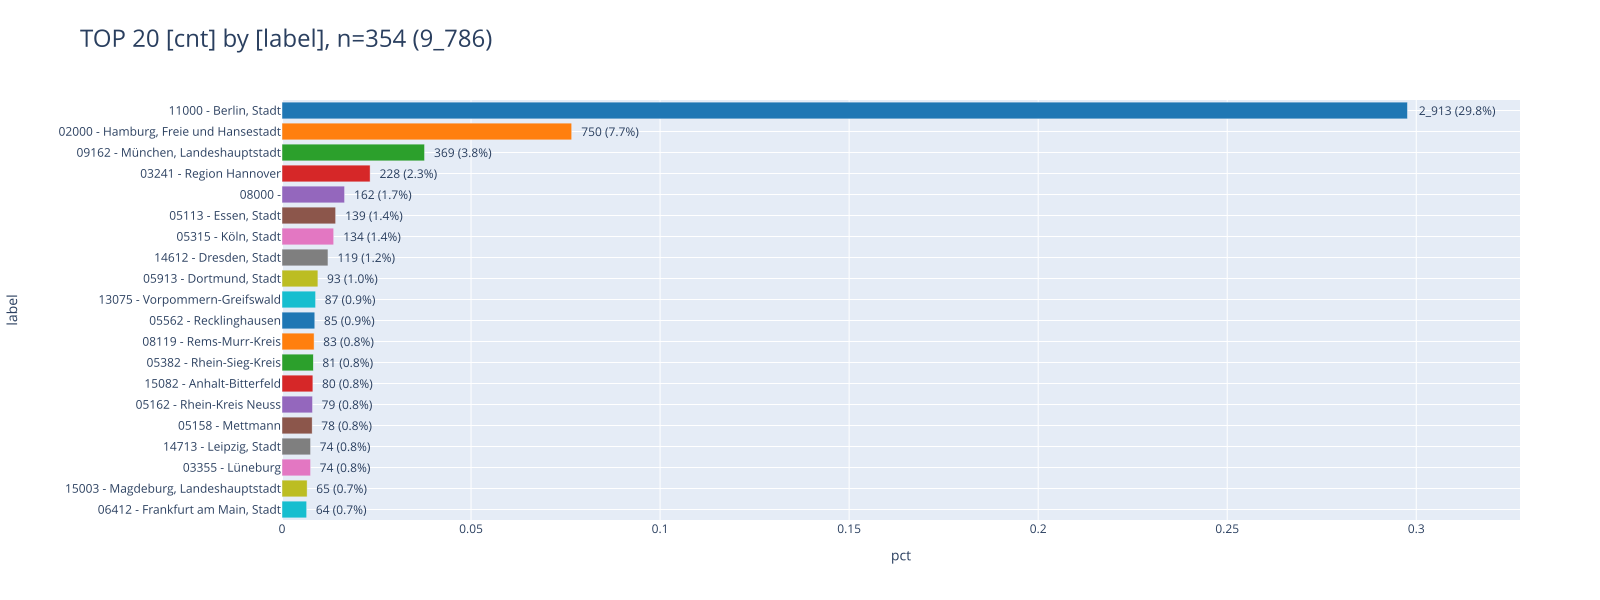

In [26]:
def show_duplikate_ort(db_duplicates, caption: str):
    _df = (db_duplicates
        .filter("not (Inzidenzort is null or Lieferregister is null)")
        .aggregate("Inzidenzort, count(*) as cnt")
        .join(dim_landkreis, "Inzidenzort::int = code", "left")
        .project("concat(Inzidenzort, ' - ', name) as label, cnt")
        .to_df()
    )#.set_index("Inzidenzort")
    # _df
    print(f"🟧 🗄️ {caption}")
    pls.plot_bars(_df, orientation="h",top_n_index=20, sort_values=True, height=600)

show_duplikate_ort(db_duplicates_clin,"klin")

🟧 🗄️ epi


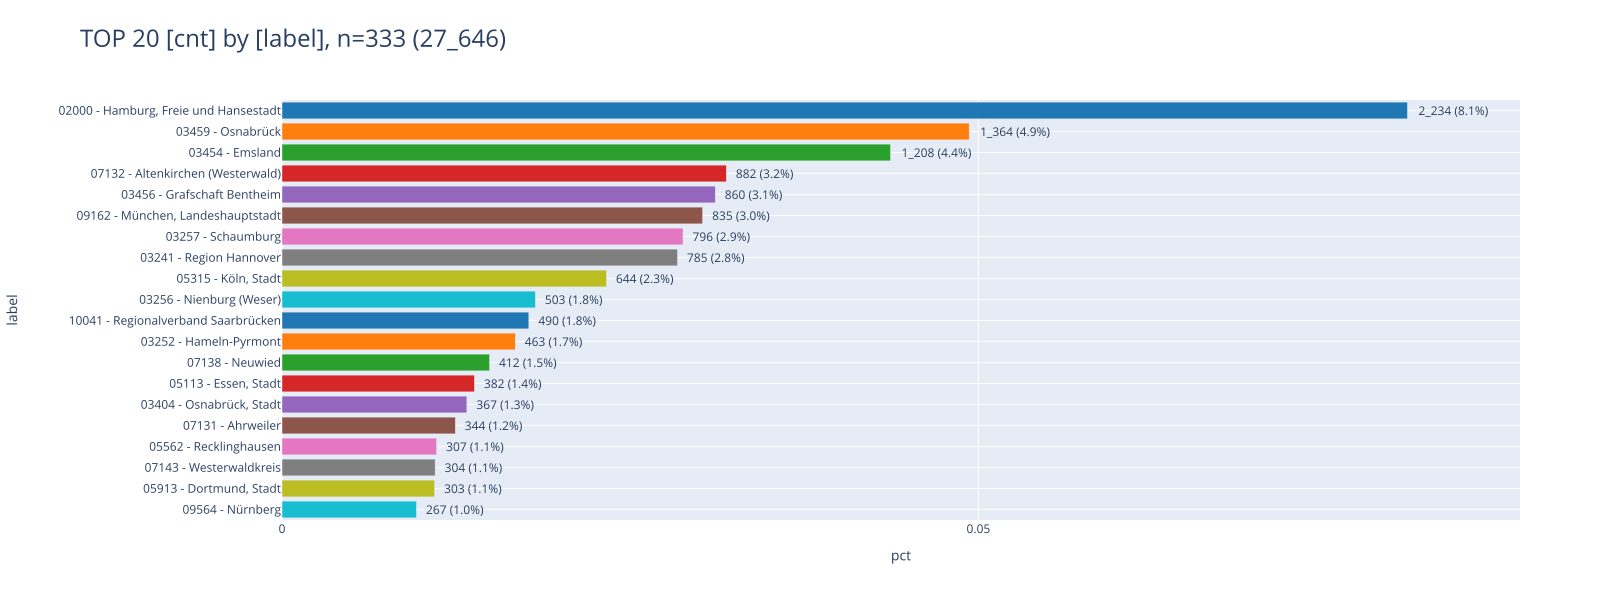

In [27]:
show_duplikate_ort(db_duplicates_epi,"epi")

<br>

#### <a id='toc1_6_2_2_'></a>[Verteilung nach Diagnosejahr](#toc0_)

🟧 🗄️ klin


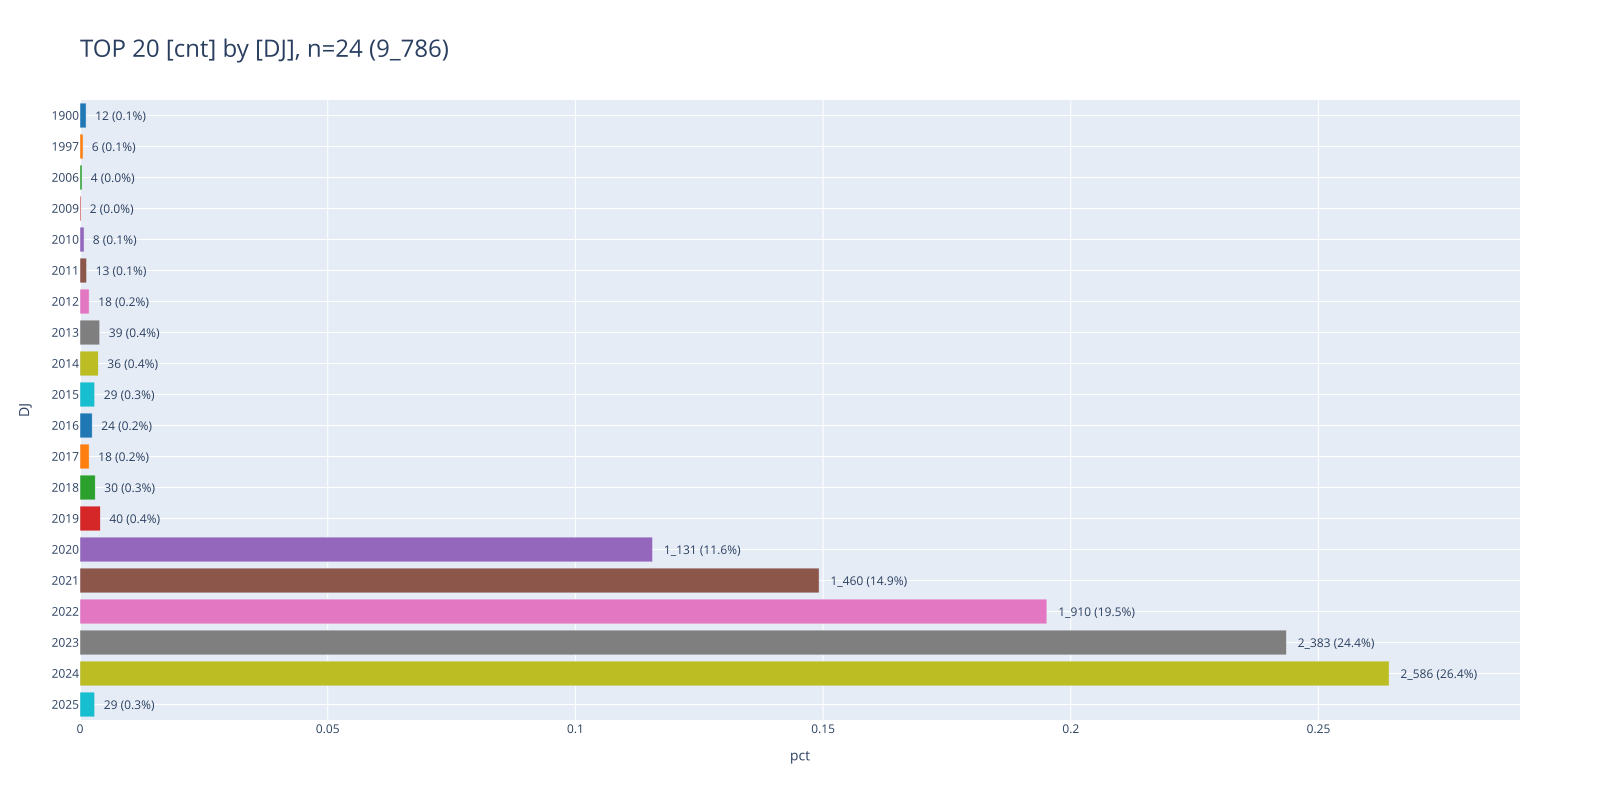

In [28]:
def show_duplikate_dj(db_duplicates, caption: str):
    _df = db_duplicates.aggregate("cast(Diagnosejahr as varchar) as DJ, count(*) as cnt").to_df()
    print(f"🟧 🗄️ {caption}")
    pls.plot_bars(_df, orientation="h",top_n_index=20, height=800, sort_values=False)

show_duplikate_dj(db_duplicates_clin, "klin")

🟧 🗄️ epi


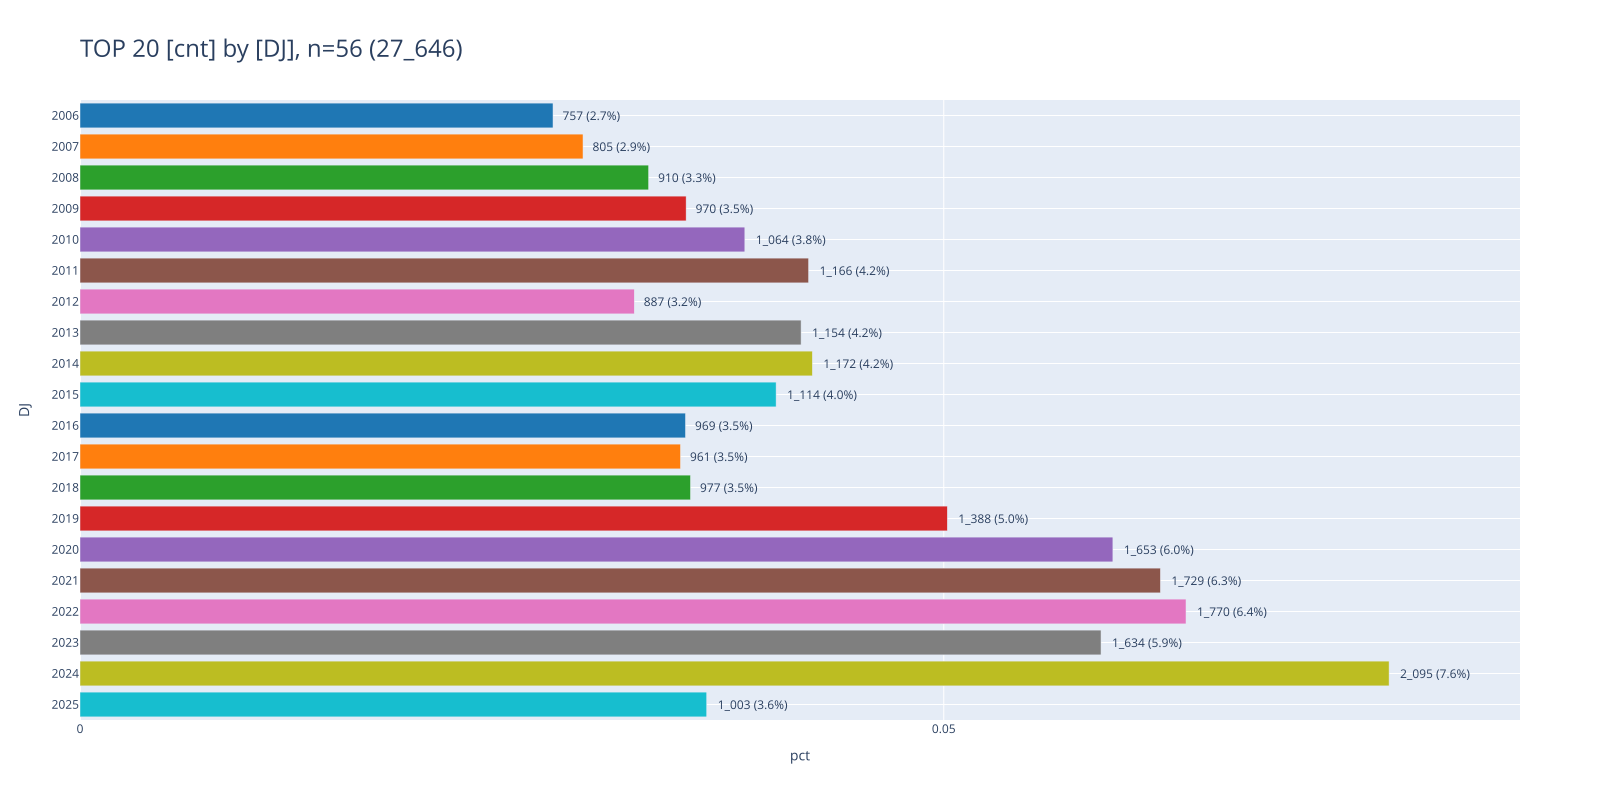

In [29]:
show_duplikate_dj(db_duplicates_epi, "epi")

<br>

#### <a id='toc1_6_2_3_'></a>[Verteilung nach ICD10](#toc0_)

🟧 🗄️ klin


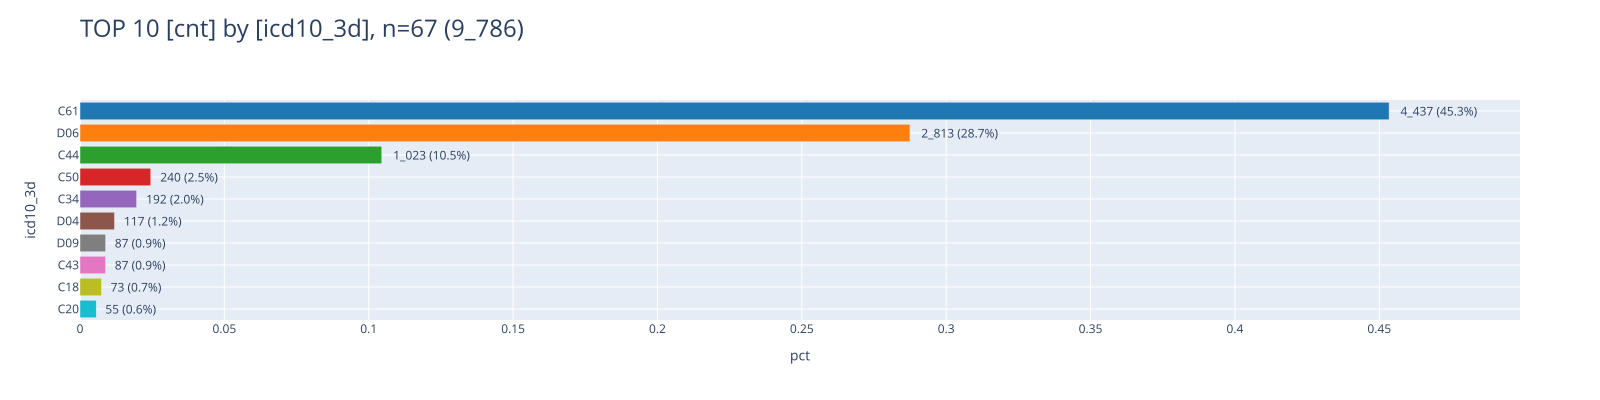

In [30]:
def show_duplikate_icd(db_duplicates, caption: str):
    _df = db_duplicates.aggregate("icd10_3d, count(*) as cnt").to_df()
    print(f"🟧 🗄️ {caption}")
    pls.plot_bars(_df, orientation="h",top_n_index=10, height=400, sort_values=True)

show_duplikate_icd(db_duplicates_clin, "klin")

🟧 🗄️ epi


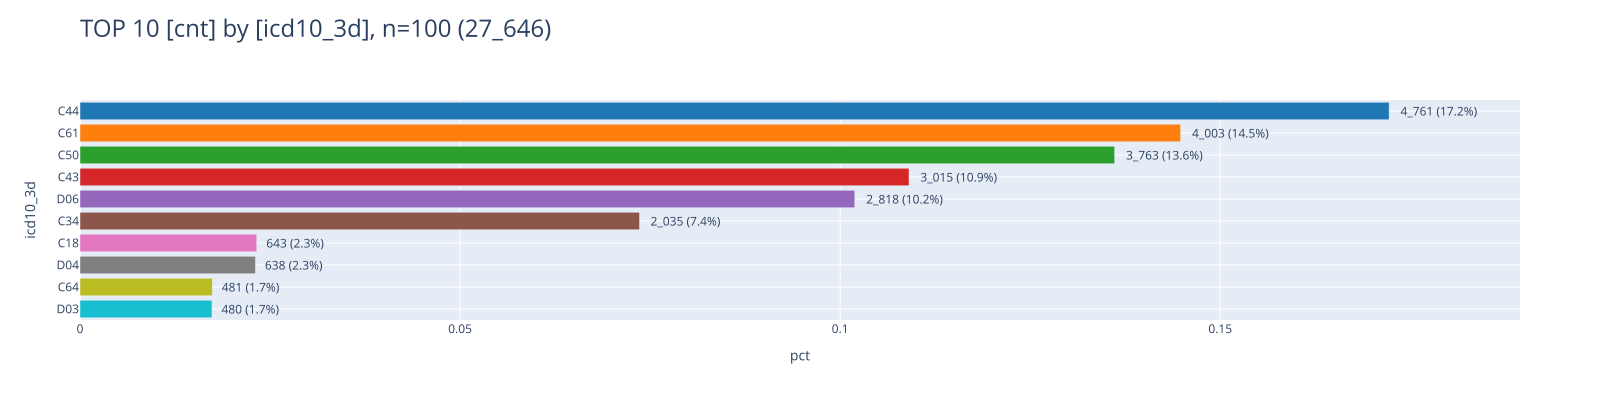

In [31]:
show_duplikate_icd(db_duplicates_epi, "epi")

<br>

#### <a id='toc1_6_2_4_'></a>[Verteilung der Gruppen mit gleichen Merkmalen](#toc0_)
- "_Gruppe_" = >1 Verdachtsfälle mit gleichen Merkmalen
- verwendete Metriken (jeweils aufgetragen: `is_equal` = "alle Fälle in der Gruppe haben den gleichen Wert")
> es gibt wenige Gruppen, in denen die Duplikate aus verschiedenen kkr stammen  
> in den meisten Gruppen stammen die Duplikate nicht von einem einzelnen Patienten  

In [32]:
def show_duplikate_grp(db_duplicates, caption: str):
    _df=(db_duplicates.aggregate("""--sql
        hash2, 
        min(Lieferregister) as kkr_min, max(Lieferregister) as kkr_max,
        min(oBDS_RKIPatientId) as pat_min, max(oBDS_RKIPatientId) as pat_max,
        count(*) as cnt
        """)
        .project("(kkr_max = kkr_min) as kkr_eq, (pat_max = pat_min) as pat_eq, cnt")
        .to_df()
    )

    print(f"🟧 🗄️ {caption}")
    print(f"{_df['cnt'].sum():_} Fälle verteilen sich auf {len(_df):_} Gruppen mit max {(_max:=_df['cnt'].max()):_} Fällen in einer Gruppe")
    print(f"Anzahl Gruppen, in denen alle Fälle das gleiche Merkmal aufweisen: REGISTER {_df['kkr_eq'].value_counts(normalize=False).to_dict()}")
    print(f"Anzahl Gruppen, in denen alle Fälle das gleiche Merkmal aufweisen: PATIENTID {_df['pat_eq'].value_counts(normalize=False).to_dict()}")

show_duplikate_grp(db_duplicates_clin,"klin")

🟧 🗄️ klin
9_786 Fälle verteilen sich auf 4_718 Gruppen mit max 14 Fällen in einer Gruppe
Anzahl Gruppen, in denen alle Fälle das gleiche Merkmal aufweisen: REGISTER {True: 4671, False: 47}
Anzahl Gruppen, in denen alle Fälle das gleiche Merkmal aufweisen: PATIENTID {False: 4265, True: 453}


In [33]:
show_duplikate_grp(db_duplicates_epi,"epi")

🟧 🗄️ epi
27_646 Fälle verteilen sich auf 13_645 Gruppen mit max 31 Fällen in einer Gruppe
Anzahl Gruppen, in denen alle Fälle das gleiche Merkmal aufweisen: REGISTER {True: 13645}
Anzahl Gruppen, in denen alle Fälle das gleiche Merkmal aufweisen: PATIENTID {False: 13362, True: 283}


In [34]:
(db_duplicates_clin
    .order("oBDS_RKIPatientId")
    # .order("hash2")
    .project("""--sql
        hash2,
        --Tumor_ID,
        *
        exclude(oBDS_RKIPatientId, Tumor_ID)
    """)
    .filter("same_pat")
    .show(max_rows=50)
)

┌──────────────────────┬─────────────────────┬──────────────────┬──────────────────┬────────────────┬────────────────┬────────────────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬───────────────────┬────────────────┬──────────┬──────────────┬─────────────┬─────────────┬────────────┬────────────┬──────────────┬──────────────────────────┬───────────────┬───────────────────────────┬───────────────────┬───────────────────────────────┬──────────────────────┬──────────────────────┬───────┬──────────┬──────────┐
│        hash2         │ Diagnose_ICD10_Code │ Morphologie_Code │ Topographie_Code │ UICC_Stadium_c │ UICC_Stadium_p │ Seitenlokalisation │   T_c   │   T_p   │ Grading │   N_p   │   N_c   │   M_c   │   M_p   │ Diagnosesicherung │ Lieferregister │ icd10_3d │ Diagnosejahr │ Inzidenzort │ Geburtsjahr │ Geschlecht │ Verstorben │ Geburtsdatum │ Geburtsdatum_Genauigkeit │ Diagnosedatum │ Diagnosedatum_Genauigkeit │ Datum_Vitalstatus │ Datum_Vitalstatus_Genauigk

## <a id='toc1_7_'></a>[Datensatz](#toc0_)

In [ ]:
tbl.describe_df(
    Tumor.project("* exclude(z_tum_id, z_pat_id, oBDS_RKIPatientTumorId, oBDS_RKIPatientId)").to_df(),
    "Tumor (id excluded)",
    fig_cols=4,
    top_n_chars_in_columns=20,
    top_n_chars_in_index=10,
    use_missing=True,
)

🔵 *** df: Tumor (id excluded) ***  
🟣 shape: (4_000_795, 101)
🟣 duplicates: 858 (0%)  
🟠 column stats all (dtype | uniques | missings) [values]  
- index [0, 1, 2, 3, 4,]  
- Diagnosedatum (datetime64[us] | 722 | 0 (0%)) [1900-04-01 00:00:00, 1937-07-15 00:00:00, 1941-01-15 00:00:00, 1945-07-01 00:00:00,  
1948-03-15 00:00:00,]  
- Diagnosedatum_Genauigkeit (object | 3 | 0 (0%)) ['M', 'T', 'V',]  
- Inzidenzort (object | 494 | 1_000 (0%)) ['01001', '01002', '01003', '01004', '01051',]  
- Diagnose_ICD10_Code (object | 884 | 393 (0%)) ['<NA>', 'C00', 'C00.0', 'C00.1', 'C00.2',]  
- Diagnose_ICD10_Version (object | 42 | 114_192 (3%)) ['10 2004 GM', '10 2006 GM', '10 2008 GM', '10 2009 GM', '10 2010 GM',]  
- Topographie_Code (object | 709 | 28_976 (1%)) ['<NA>', 'C00.0', 'C00.1', 'C00.2', 'C00.3',]  
- Topographie_Version (object | 4 | 128_871 (3%)) ['31', '32', '33', '<NA>',]  
- Diagnosesicherung (object | 12 | 0 (0%)) ['0', '1', '2', '4', '5',]  
- TNM_Auflage_c (object | 5 | 1_826_56

<!-- START_TOKEN -->

<!-- END_TOKEN -->

┌─────────────────────┬──────────────────────┬─────────────┬───┬─────────┬──────────────────────┬──────────────────────┐
│    Diagnosedatum    │ Diagnosedatum_Gena…  │ Inzidenzort │ … │  z_sex  │ z_period_diag_deat…  │ z_period_diag_psa_…  │
│      timestamp      │       varchar        │   varchar   │   │ varchar │        int32         │        int32         │
├─────────────────────┼──────────────────────┼─────────────┼───┼─────────┼──────────────────────┼──────────────────────┤
│ 2022-06-15 00:00:00 │ T                    │ 06439       │ … │ M       │                  127 │                 NULL │
│ 2021-09-15 00:00:00 │ T                    │ 14625       │ … │ W       │                 NULL │                 NULL │
│ 2024-08-15 00:00:00 │ T                    │ 09277       │ … │ W       │                 NULL │                 NULL │
├─────────────────────┴──────────────────────┴─────────────┴───┴─────────┴──────────────────────┴──────────────────────┤
│ 3 rows                        

Error in callback <function flush_figures at 0x4ae841b20> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 